In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns
import time

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: []


Full training data shape: (50000, 32, 32, 3)
Full test data shape: (10000, 32, 32, 3)
Using train shape: (15000, 32, 32, 3) | test shape: (3000, 32, 32, 3)


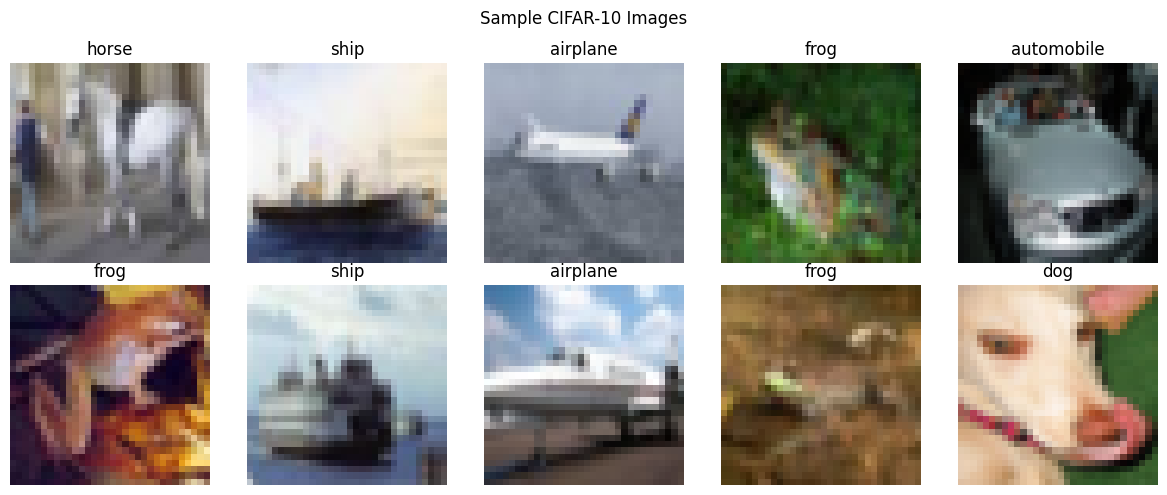

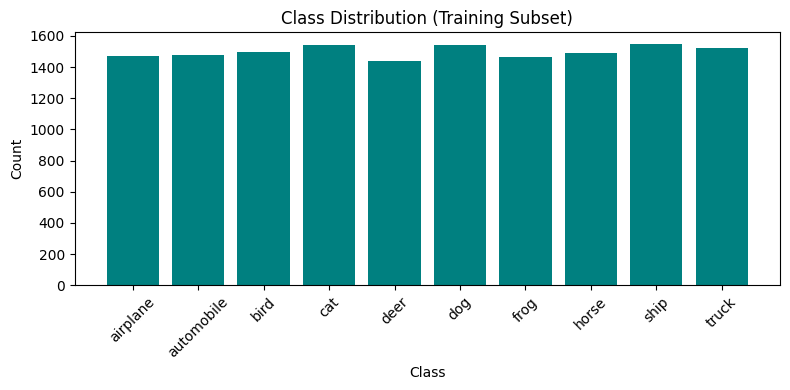

In [9]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Full training data shape:", x_train_full.shape)
print("Full test data shape:", x_test_full.shape)

# ---- Subsample for speed (stratified-ish, keeps class balance reasonable) ----
N_TRAIN, N_TEST = 15000, 3000
train_idx = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
test_idx  = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]
x_test, y_test   = x_test_full[test_idx], y_test_full[test_idx]

# Normalize
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
y_train_flat = y_train.flatten()
y_test_flat  = y_test.flatten()

print("Using train shape:", x_train.shape, "| test shape:", x_test.shape)

# ---- Display 10 sample images ----
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train_flat[i]])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

# ---- Class distribution ----
unique, counts = np.unique(y_train_flat, return_counts=True)
plt.figure(figsize=(8,4))
plt.bar([class_names[i] for i in unique], counts, color='teal')
plt.title("Class Distribution (Training Subset)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
sample_img = np.expand_dims(x_train[0], axis=0)  # shape (1,32,32,3)

kernel_sizes = [3, 5, 7]
print("Input image shape:", sample_img.shape)
print("-"*50)

for k in kernel_sizes:
    conv_layer = layers.Conv2D(filters=8, kernel_size=k, strides=1,
                                padding='valid', activation='relu')
    output = conv_layer(sample_img)
    expected_size = (32 - k) // 1 + 1
    print(f"Kernel {k}x{k}  ->  Feature map shape: {output.shape[1:]}"
          f"   (formula check: {expected_size}x{expected_size})")

Input image shape: (1, 32, 32, 3)
--------------------------------------------------
Kernel 3x3  ->  Feature map shape: (30, 30, 8)   (formula check: 30x30)
Kernel 5x5  ->  Feature map shape: (28, 28, 8)   (formula check: 28x28)
Kernel 7x7  ->  Feature map shape: (26, 26, 8)   (formula check: 26x26)


In [11]:
configs = [
    {"stride": 1, "padding": "valid"},
    {"stride": 2, "padding": "valid"},
    {"stride": 1, "padding": "same"},
    {"stride": 2, "padding": "same"},
]

print(f"{'Stride':<8}{'Padding':<10}{'Output Shape'}")
print("-"*40)
for cfg in configs:
    conv_layer = layers.Conv2D(filters=8, kernel_size=3,
                                strides=cfg["stride"], padding=cfg["padding"])
    out = conv_layer(sample_img)
    print(f"{cfg['stride']:<8}{cfg['padding']:<10}{tuple(out.shape[1:])}")

Stride  Padding   Output Shape
----------------------------------------
1       valid     (30, 30, 8)
2       valid     (15, 15, 8)
1       same      (32, 32, 8)
2       same      (16, 16, 8)


In [12]:
def build_cnn(pooling='max', filters1=16, filters2=32):
    Pool = layers.MaxPooling2D if pooling == 'max' else layers.AveragePooling2D
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(filters1, (3,3), activation='relu', padding='same', name='conv1'),
        Pool((2,2)),
        layers.Conv2D(filters2, (3,3), activation='relu', padding='same'),
        Pool((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_cnn(pooling='max')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,874 (534.66 KB)

 Trainable params: 136,874 (534.66 KB)

 Non-trainable params: 0 (0.00 B)

Feature map tensor shape: (1, 32, 32, 16)


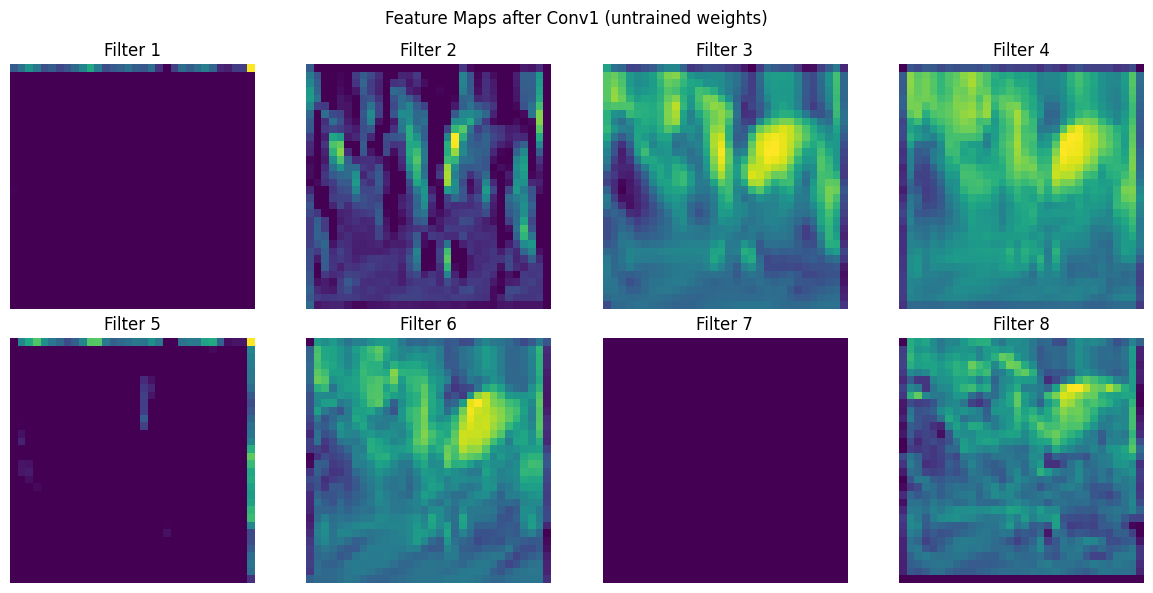

In [13]:
feature_map_model = models.Model(inputs=model.inputs,
                                  outputs=model.get_layer('conv1').output)
feature_maps = feature_map_model.predict(sample_img, verbose=0)
print("Feature map tensor shape:", feature_maps.shape)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.title(f"Filter {i+1}")
    plt.axis('off')
plt.suptitle("Feature Maps after Conv1 (untrained weights)")
plt.tight_layout()
plt.show()

In [14]:
results_pooling = {}

for pool_type in ['max', 'avg']:
    m = build_cnn(pooling=pool_type)
    t0 = time.time()
    hist = m.fit(x_train, y_train_flat, epochs=4, batch_size=64,
                 validation_split=0.1, verbose=0)
    t1 = time.time()
    test_loss, test_acc = m.evaluate(x_test, y_test_flat, verbose=0)
    results_pooling[pool_type] = {
        "val_acc": hist.history['val_accuracy'][-1],
        "test_acc": test_acc,
        "time": t1 - t0
    }

print(f"{'Pooling':<10}{'Val Acc':<12}{'Test Acc':<12}{'Time (s)'}")
for k, v in results_pooling.items():
    print(f"{k:<10}{v['val_acc']:<12.4f}{v['test_acc']:<12.4f}{v['time']:.1f}")

Pooling   Val Acc     Test Acc    Time (s)
max       0.5727      0.5593      70.8
avg       0.5087      0.4900      61.6


In [15]:
model = build_cnn(pooling='max', filters1=32, filters2=64)

EPOCHS = 12
BATCH_SIZE = 64

t0 = time.time()
history = model.fit(x_train, y_train_flat,
                     epochs=EPOCHS,
                     batch_size=BATCH_SIZE,
                     validation_split=0.1,
                     verbose=1)
print(f"\nTraining time: {time.time()-t0:.1f} seconds")

Epoch 1/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.3437 - loss: 1.8014 - val_accuracy: 0.4173 - val_loss: 1.6037
Epoch 2/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.4933 - loss: 1.4161 - val_accuracy: 0.4960 - val_loss: 1.4365
Epoch 3/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 113ms/step - accuracy: 0.5555 - loss: 1.2602 - val_accuracy: 0.5593 - val_loss: 1.2650
Epoch 4/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.5959 - loss: 1.1518 - val_accuracy: 0.5773 - val_loss: 1.2024
Epoch 5/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.6312 - loss: 1.0505 - val_accuracy: 0.6020 - val_loss: 1.1676
Epoch 6/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.6616 - loss: 0.9718 - val_accuracy: 0.6047 - val_loss: 1.1488
Epoch 7/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - accuracy: 0.6840 - loss: 0.9042 - val_accuracy: 0.6113 - val_loss: 1.1247
Epoch 8/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0.7032 - loss: 0

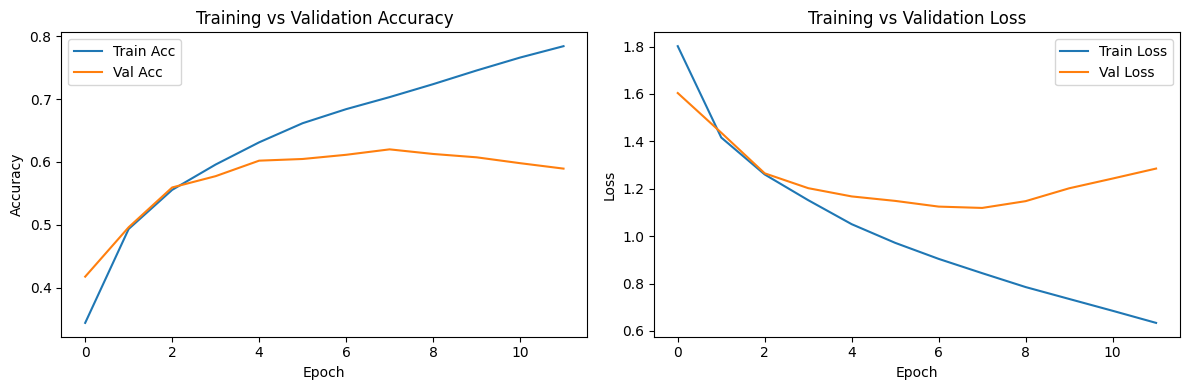

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

Test Accuracy : 0.5963
Precision (macro) : 0.6371
Recall (macro)    : 0.5992
F1-score (macro)  : 0.6004

Classification Report:
              precision    recall  f1-score   support

    airplane       0.49      0.79      0.60       279
  automobile       0.82      0.70      0.75       290
        bird       0.57      0.37      0.45       318
         cat       0.43      0.43      0.43       303
        deer       0.47      0.66      0.55       309
         dog       0.51      0.60      0.55       315
        frog       0.80      0.57      0.66       292
       horse       0.60      0.72      0.66       292
        ship       0.92      0.49      0.64       295
       truck       0.77      0.66      0.71       307

    accuracy                           0.60      3000
   macro avg       0.64      0.60      0.60      3000
weighted avg       0.64      0.60      0.60      3000



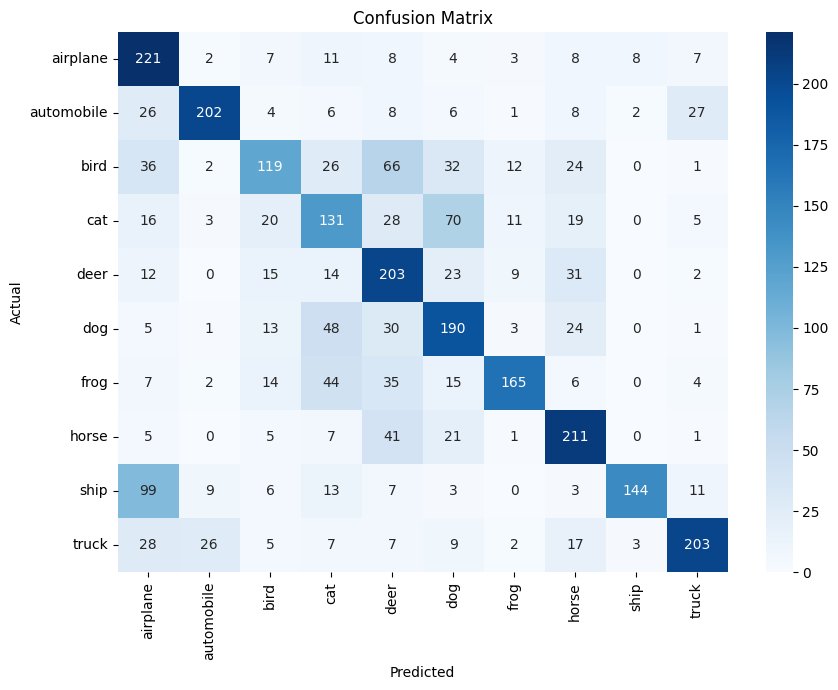

In [17]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test_flat, y_pred)
prec = precision_score(y_test_flat, y_pred, average='macro')
rec = recall_score(y_test_flat, y_pred, average='macro')
f1 = f1_score(y_test_flat, y_pred, average='macro')

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision (macro) : {prec:.4f}")
print(f"Recall (macro)    : {rec:.4f}")
print(f"F1-score (macro)  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred, target_names=class_names))

cm = confusion_matrix(y_test_flat, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [18]:
total_params = model.count_params()
print("Total trainable parameters:", total_params)
model.summary()

Total trainable parameters: 282250


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 846,752 (3.23 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 564,502 (2.15 MB)

In [19]:

N, F, P, S = 64, 5, 2, 2
out_size = (N - F + 2*P)//S + 1
print(f"Ex1: Output size = {out_size}x{out_size}")

filters, k, in_ch = 64, 3, 3
params = (k*k*in_ch + 1) * filters
print(f"Ex2: Trainable parameters = {params}")

for f1, f2 in [(16,32), (64,128)]:
    m = build_cnn(pooling='max', filters1=f1, filters2=f2)
    t0 = time.time()
    h = m.fit(x_train, y_train_flat, epochs=3, batch_size=64, validation_split=0.1, verbose=0)
    dur = time.time()-t0
    test_loss, test_acc = m.evaluate(x_test, y_test_flat, verbose=0)
    print(f"Filters {f1}->{f2}: test_acc={test_acc:.4f}, time={dur:.1f}s, params={m.count_params()}")

Ex1: Output size = 32x32
Ex2: Trainable parameters = 1792
Filters 16->32: test_acc=0.5227, time=55.6s, params=136874
Filters 64->128: test_acc=0.5477, time=170.3s, params=600650
